## 3 Technical Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

## 4 Load Dataset

In [2]:
df = pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## 5 Data Quality Assessment 

The purpose of this section is to assess the completeness, structure, and suitability of the dataset before analysis. This includes checking for missing values, reviewing variable types, and identifying any issues that may require preprocessing.

## 6 Data Quality Checks

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [4]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [5]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


### Data Quality Summary

The dataset contains 6,435 observations across 45 Walmart stores, with 8 variables describing weekly sales and related economic indicators.

No missing values were detected across any variables, indicating that the dataset is complete and suitable for analysis without requiring imputation.

Weekly sales vary substantially across observations, highlighting the importance of accurate forecasting in retail planning and operational management. The Date variable must be converted into datetime format to support time-series analysis.

## 8. Feature Engineering & Preprocessing

The raw store-level sales data was transformed into a weekly aggregated dataset to support forecasting. Sales were summed across stores by week, while holiday and macroeconomic variables were retained using appropriate aggregation methods.

Additional temporal and lag-based features were created to capture seasonality, trend, and recent sales momentum. These features improve the predictive potential of the dataset and make it more suitable for both linear and non-linear forecasting models.

In [6]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

weekly_total = (
    df.groupby('Date', as_index=False)
    .agg({
        'Weekly_Sales': 'sum',
        'Holiday_Flag': 'max',
        'Temperature': 'mean',
        'Fuel_Price': 'mean',
        'CPI': 'mean',
        'Unemployment': 'mean'
    })
    .sort_values('Date')
    .reset_index(drop=True)
)

weekly_total.head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750740.50,0,34.037333,2.717844,167.730885,8.619311
1,2010-02-12,48336677.63,1,34.151333,2.694022,167.825608,8.619311
2,2010-02-19,48276993.78,0,37.719778,2.672067,167.871686,8.619311
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311


In [7]:
weekly_total['Month'] = weekly_total['Date'].dt.month
weekly_total['Year'] = weekly_total['Date'].dt.year
weekly_total['Week'] = weekly_total['Date'].dt.isocalendar().week.astype(int)

weekly_total['Rolling_4wk'] = weekly_total['Weekly_Sales'].rolling(window=4).mean()
weekly_total['Lag_1'] = weekly_total['Weekly_Sales'].shift(1)
weekly_total['Lag_2'] = weekly_total['Weekly_Sales'].shift(2)
weekly_total['Time_Index'] = range(len(weekly_total))

weekly_total = weekly_total.dropna()

weekly_total.head()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year,Week,Rolling_4wk,Lag_1,Lag_2,Time_Index
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311,2,2010,8,4.758325e+07,48276993.78,48336677.63,3
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311,3,2010,9,4.686343e+07,43968571.13,48276993.78,4
5,2010-03-12,45925396.51,0,47.432444,2.774422,167.985598,8.619311,3,2010,10,4.626061e+07,46871470.30,43968571.13,5
6,2010-03-19,44988974.64,0,49.954222,2.817089,167.930427,8.619311,3,2010,11,4.543860e+07,45925396.51,46871470.30,6
7,2010-03-26,44133961.05,0,48.473556,2.824111,167.859731,8.619311,3,2010,12,4.547995e+07,44988974.64,45925396.51,7


## 11. Exploratory Data Analysis (EDA)

This section explores the main patterns in the dataset, including long-term trends, seasonality, holiday effects, sales distribution, and relationships between variables. The goal is to understand the structure of the data before forecasting models are applied.

## 12 Sales Trend Over Time

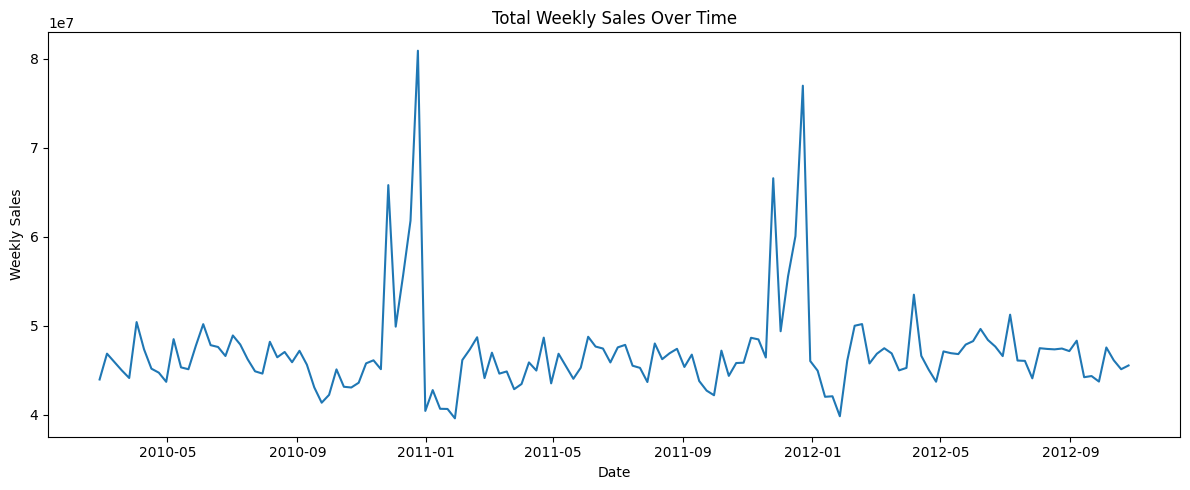

In [8]:
plt.figure(figsize=(12,5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'])
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

The weekly sales series shows relatively stable baseline performance with noticeable seasonal peaks, particularly toward the end of each year. These spikes suggest that sales are strongly influenced by recurring seasonal demand patterns.

## Rolling Average Trend

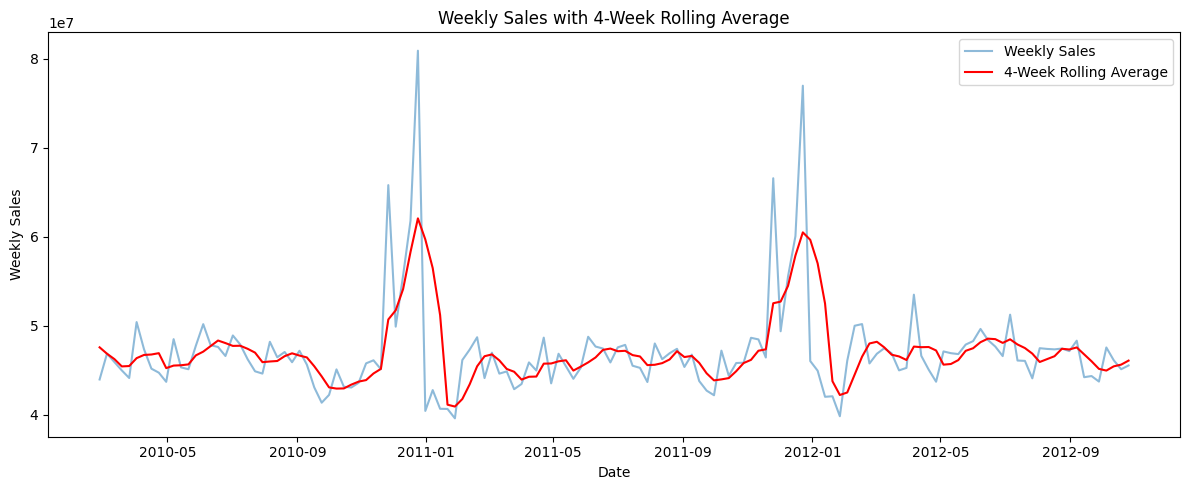

In [9]:
plt.figure(figsize=(12,5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'], alpha=0.5, label='Weekly Sales')
plt.plot(weekly_total['Date'], weekly_total['Rolling_4wk'], color='red', label='4-Week Rolling Average')
plt.title("Weekly Sales with 4-Week Rolling Average")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()

The 4-week rolling average smooths short-term fluctuations and highlights the underlying trend in sales. It confirms that the sales series is largely stable over time, with clear seasonal peaks between October and December followed by a sharp drop in January.

## Monthly Seasonality

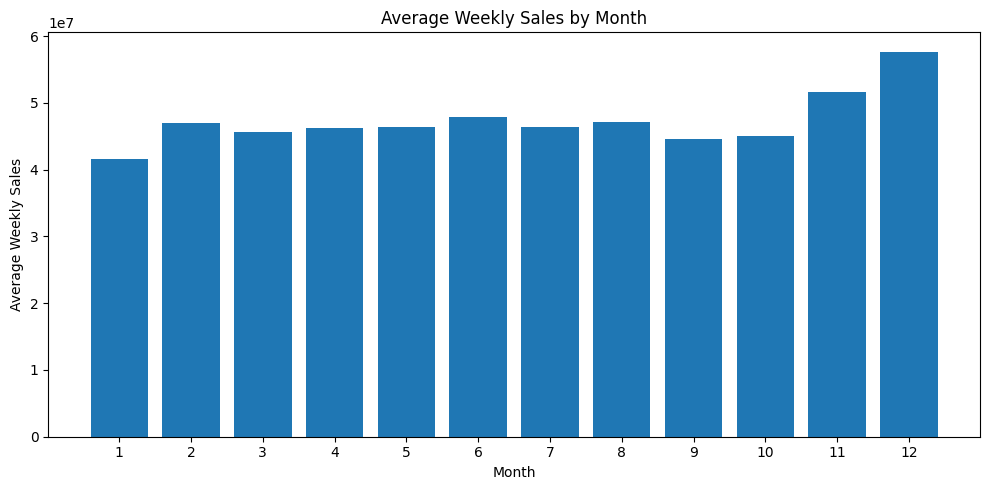

In [10]:
monthly_avg = (
    weekly_total
    .groupby('Month')['Weekly_Sales']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.bar(monthly_avg['Month'], monthly_avg['Weekly_Sales'])
plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

Average weekly sales by month indicate moderate but consistent seasonality. December records the highest sales levels, while January experiences a decline, reflecting typical post-holiday contraction in consumer spending.

## Holiday Effect Analysis

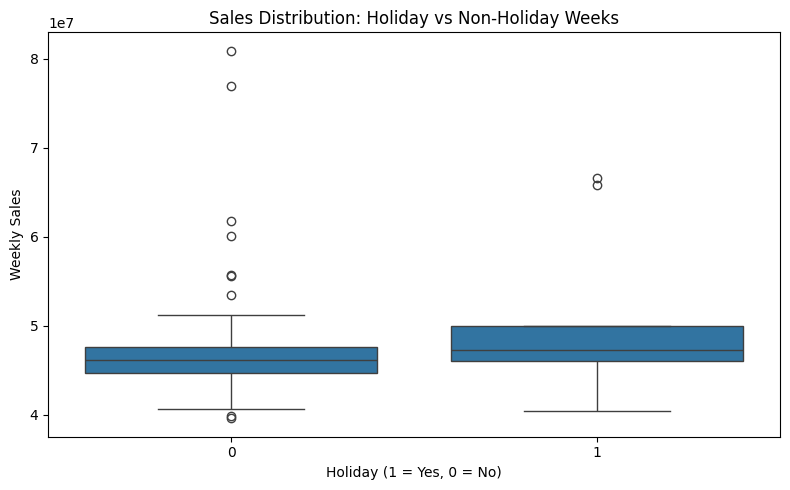

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=weekly_total)
plt.title("Sales Distribution: Holiday vs Non-Holiday Weeks")
plt.xlabel("Holiday (1 = Yes, 0 = No)")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

The distribution of weekly sales is positively skewed, with most observations concentrated at moderate values and a smaller number of high-value observations extending the distribution to the right. These extreme values likely correspond to holiday or seasonal peaks.

## Correlation Analysis

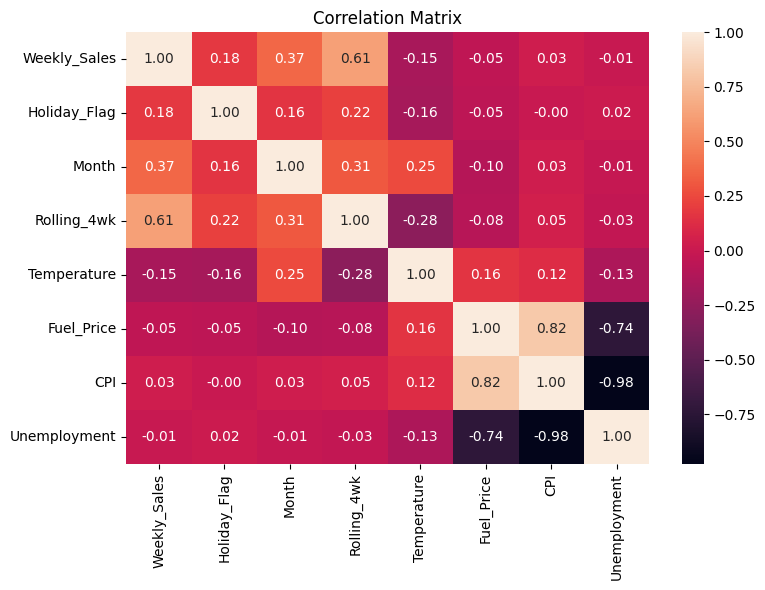

In [12]:
corr = weekly_total[['Weekly_Sales','Holiday_Flag','Month','Rolling_4wk','Temperature','Fuel_Price','CPI','Unemployment']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The correlation matrix reveals that the rolling 4-week average has the strongest relationship with weekly sales, indicating that recent trends are highly predictive. Seasonal and event-based variables also contribute to variation in sales, while macroeconomic indicators show weaker but still relevant relationships.